In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDRegressor
sns.set_style("whitegrid")



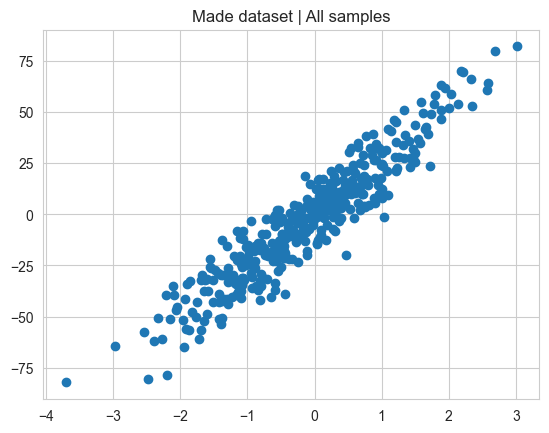

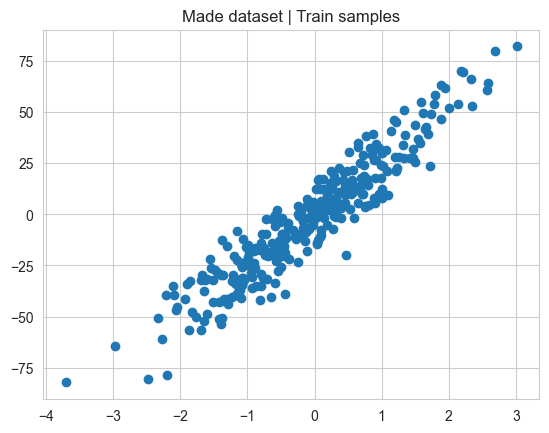

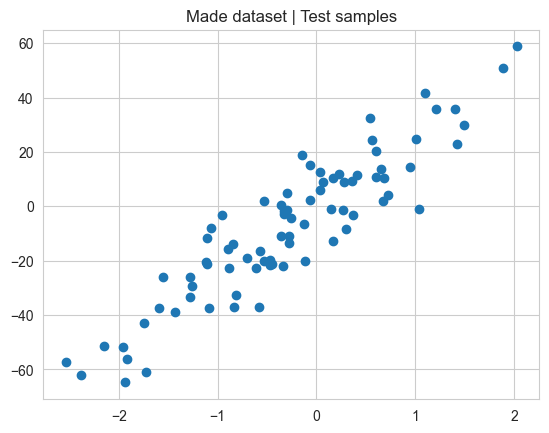

In [74]:
X,Y = make_regression(400,1,n_informative=1,noise=10)
x_train, x_test, y_train,y_test = train_test_split(X,Y, test_size=0.2)

plt.scatter(X,Y)
plt.title("Made dataset | All samples")
plt.show()

plt.scatter(x_train,y_train)
plt.title("Made dataset | Train samples")
plt.show()

plt.scatter(x_test,y_test)
plt.title("Made dataset | Test samples")
plt.show()

In [75]:
lr = LinearRegression()
lr.fit(x_train, y_train)

# y_pred = lr.predict(x_test)
score = lr.score(x_test,y_test)
score

0.83945873802405

In [76]:
_x_range = np.arange(-3,+3,0.1)
_x_range

array([-3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01,  2.66453526e-15,  1.00000000e-01,
        2.00000000e-01,  3.00000000e-01,  4.00000000e-01,  5.00000000e-01,
        6.00000000e-01,  7.00000000e-01,  8.00000000e-01,  9.00000000e-01,
        1.00000000e+00,  1.10000000e+00,  1.20000000e+00,  1.30000000e+00,
        1.40000000e+00,  1.50000000e+00,  1.60000000e+00,  1.70000000e+00,
        1.80000000e+00,  1.90000000e+00,  2.00000000e+00,  2.10000000e+00,
        2.20000000e+00,  

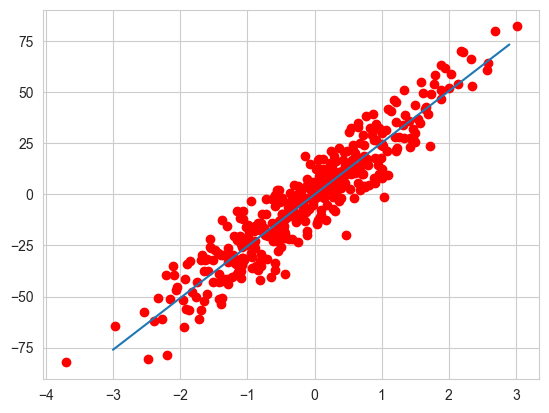

In [77]:
_x_range_re = np.reshape(_x_range,(-1,1))
y_pred = lr.predict(_x_range_re)

plt.scatter(X,Y,color="red")
plt.plot(_x_range,y_pred)
plt.show()

Getting the fish+market dataset from kaggle
https://www.kaggle.com/datasets/vipullrathod/fish-market?select=Fish.csv

In [78]:
raw_data = pd.read_csv("./Fish.csv").set_axis([0,1,2,3,4,5,6], axis=1)
Y = np.array(raw_data.pop(1))
X = np.array(raw_data)

raw_data


,0,2,3,4,5,6
0,Bream,23.2,25.4,30.0,11.5200,4.0200
1,Bream,24.0,26.3,31.2,12.4800,4.3056
2,Bream,23.9,26.5,31.1,12.3778,4.6961
3,Bream,26.3,29.0,33.5,12.7300,4.4555
4,Bream,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,13.2,14.3,15.2,2.8728,2.0672


In [79]:
Y = pd.DataFrame(Y)
X = pd.DataFrame(X)
X_encoded = pd.get_dummies(X, columns=[0], drop_first=True)
X_encoded = X_encoded.astype(float)
X_encoded.columns = X_encoded.columns.astype(str)
X_encoded

,1,2,3,4,5,0_Parkki,0_Perch,0_Pike,0_Roach,0_Smelt,0_Whitefish
0,23.2,25.4,30.0,11.5200,4.0200,0.0,0.0,0.0,0.0,0.0,0.0
1,24.0,26.3,31.2,12.4800,4.3056,0.0,0.0,0.0,0.0,0.0,0.0
2,23.9,26.5,31.1,12.3778,4.6961,0.0,0.0,0.0,0.0,0.0,0.0
3,26.3,29.0,33.5,12.7300,4.4555,0.0,0.0,0.0,0.0,0.0,0.0
4,26.5,29.0,34.0,12.4440,5.1340,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
154,11.5,12.2,13.4,2.0904,1.3936,0.0,0.0,0.0,0.0,1.0,0.0
155,11.7,12.4,13.5,2.4300,1.2690,0.0,0.0,0.0,0.0,1.0,0.0
156,12.1,13.0,13.8,2.2770,1.2558,0.0,0.0,0.0,0.0,1.0,0.0
157,13.2,14.3,15.2,2.8728,2.0672,0.0,0.0,0.0,0.0,1.0,0.0


In [80]:
x_train, x_test, y_train,y_test = train_test_split(X_encoded,Y, test_size=0.2)
print(x_test.shape, x_train.shape)

(32, 11) (127, 11)


In [81]:
print(x_train.head())

        1     2     3        4       5  0_Parkki  0_Perch  0_Pike  0_Roach  \
73   12.5  13.7  14.7   3.5280  1.9992       0.0      1.0     0.0      0.0   
111  32.5  35.0  37.3  11.4884  7.7957       0.0      1.0     0.0      0.0   
57   25.6  28.0  30.8   8.7780  4.6816       0.0      0.0     0.0      0.0   
41   19.1  20.8  23.1   6.1677  3.3957       0.0      0.0     0.0      1.0   
120  37.0  40.0  42.5  11.7300  7.2250       0.0      1.0     0.0      0.0   

     0_Smelt  0_Whitefish  
73       0.0          0.0  
111      0.0          0.0  
57       0.0          1.0  
41       0.0          0.0  
120      0.0          0.0  


In [82]:
# x_train = pd.DataFrame(x_train)
# x_train

In [83]:
# one_hot = pd.get_dummies(x_train[[0]],drop_first=True)
# x_train = x_train.drop(0,axis=1)
# x_train = x_train.join(one_hot)
# x_train

In [84]:
cols_to_scale = ['1', '2', '3', '4', '5']

min_max_scaler = MinMaxScaler()
x = x_train[cols_to_scale].values
x_scaled = min_max_scaler.fit_transform(x)
normalized = pd.DataFrame(x_scaled, columns=cols_to_scale, index=x_train.index)
x_train[cols_to_scale] = normalized

x_train

,1,2,3,4,5,0_Parkki,0_Perch,0_Pike,0_Roach,0_Smelt,0_Whitefish
73,0.097087,0.096364,0.099662,0.103913,0.141017,0.0,1.0,0.0,0.0,0.0,0.0
111,0.485437,0.483636,0.481419,0.566238,1.000000,0.0,1.0,0.0,0.0,0.0,0.0
57,0.351456,0.356364,0.371622,0.408823,0.538522,0.0,0.0,0.0,0.0,0.0,1.0
41,0.225243,0.225455,0.241554,0.257222,0.347965,0.0,0.0,0.0,1.0,0.0,0.0
120,0.572816,0.574545,0.569257,0.580270,0.915428,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
123,0.611650,0.610909,0.604730,0.642425,0.862584,0.0,1.0,0.0,0.0,0.0,0.0
130,0.489320,0.483636,0.506757,0.243789,0.494480,0.0,0.0,1.0,0.0,0.0,0.0
49,0.281553,0.272727,0.302365,0.300641,0.382863,0.0,0.0,0.0,1.0,0.0,0.0
66,0.223301,0.223636,0.243243,0.394861,0.332953,1.0,0.0,0.0,0.0,0.0,0.0


In [85]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127 entries, 73 to 133
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   1            127 non-null    float64
 1   2            127 non-null    float64
 2   3            127 non-null    float64
 3   4            127 non-null    float64
 4   5            127 non-null    float64
 5   0_Parkki     127 non-null    float64
 6   0_Perch      127 non-null    float64
 7   0_Pike       127 non-null    float64
 8   0_Roach      127 non-null    float64
 9   0_Smelt      127 non-null    float64
 10  0_Whitefish  127 non-null    float64
dtypes: float64(11)
memory usage: 11.9 KB


In [86]:
y_train = pd.DataFrame(y_train)
y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127 entries, 73 to 133
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       127 non-null    float64
dtypes: float64(1)
memory usage: 2.0 KB


In [87]:
lr_2 = LinearRegression()
# lr_2.fit(np.array(x_train), np.array(y_train))
lr_2.fit(x_train, y_train)
x_test


,1,2,3,4,5,0_Parkki,0_Perch,0_Pike,0_Roach,0_Smelt,0_Whitefish
114,34.5,37.0,39.4,10.8350,6.2646,0.0,1.0,0.0,0.0,0.0,0.0
43,20.4,22.0,24.7,5.8045,3.7544,0.0,0.0,0.0,1.0,0.0,0.0
158,13.8,15.0,16.2,2.9322,1.8792,0.0,0.0,0.0,0.0,1.0,0.0
126,40.2,43.5,46.0,12.6040,8.1420,0.0,1.0,0.0,0.0,0.0,0.0
76,15.7,17.4,18.5,4.5880,2.9415,0.0,1.0,0.0,0.0,0.0,0.0
4,26.5,29.0,34.0,12.4440,5.1340,0.0,0.0,0.0,0.0,0.0,0.0
147,10.1,10.6,11.6,1.7284,1.1484,0.0,0.0,0.0,0.0,1.0,0.0
44,20.5,22.0,24.3,6.6339,3.5478,0.0,0.0,0.0,1.0,0.0,0.0
34,38.0,41.0,46.5,17.6235,6.3705,0.0,0.0,0.0,0.0,0.0,0.0
12,29.1,31.5,36.4,13.7592,4.3680,0.0,0.0,0.0,0.0,0.0,0.0


In [88]:
x = x_test[cols_to_scale].values
x_scaled = min_max_scaler.transform(x)
normalized = pd.DataFrame(x_scaled, columns=cols_to_scale, index=x_test.index)
x_test[cols_to_scale] = normalized
y_test

,0
114,700.0
43,150.0
158,19.9
126,1000.0
76,70.0
4,430.0
147,7.0
44,145.0
34,950.0
12,500.0


In [89]:
score = lr_2.score(x_test,y_test)
print(score)

0.9539427314035146


In [90]:
lr_gd = SGDRegressor(max_iter=20000, tol=0.0001, verbose=1)
lr_gd.fit(x_train, np.ravel(y_train))
score = lr_gd.score(x_test, np.ravel(y_test))
score

-- Epoch 1
Norm: 168.68, NNZs: 11, Bias: 112.432185, T: 127, Avg. loss: 76790.271487
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 229.64, NNZs: 11, Bias: 136.787352, T: 254, Avg. loss: 41817.874538
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 264.38, NNZs: 11, Bias: 141.491498, T: 381, Avg. loss: 34054.380440
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 287.50, NNZs: 11, Bias: 138.033138, T: 508, Avg. loss: 30797.886662
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 306.14, NNZs: 11, Bias: 132.534753, T: 635, Avg. loss: 28763.707766
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 321.29, NNZs: 11, Bias: 125.426091, T: 762, Avg. loss: 27169.099130
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 334.96, NNZs: 11, Bias: 118.369053, T: 889, Avg. loss: 25860.605796
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 346.49, NNZs: 11, Bias: 110.522345, T: 1016, Avg. loss: 24696.095348
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 357.56, NNZs: 11, Bias


Total training time: 0.04 seconds.
-- Epoch 1569
Norm: 944.25, NNZs: 11, Bias: -388.924686, T: 199263, Avg. loss: 5269.994760
Total training time: 0.04 seconds.
-- Epoch 1570
Norm: 944.31, NNZs: 11, Bias: -388.976325, T: 199390, Avg. loss: 5269.738282
Total training time: 0.04 seconds.
-- Epoch 1571
Norm: 944.40, NNZs: 11, Bias: -389.005006, T: 199517, Avg. loss: 5269.475699
Total training time: 0.04 seconds.
-- Epoch 1572
Norm: 944.45, NNZs: 11, Bias: -389.076918, T: 199644, Avg. loss: 5269.018277
Total training time: 0.04 seconds.
-- Epoch 1573
Norm: 944.50, NNZs: 11, Bias: -389.137872, T: 199771, Avg. loss: 5268.768500
Total training time: 0.04 seconds.
-- Epoch 1574
Norm: 944.60, NNZs: 11, Bias: -389.162646, T: 199898, Avg. loss: 5268.670139
Total training time: 0.04 seconds.
-- Epoch 1575
Norm: 944.68, NNZs: 11, Bias: -389.196017, T: 200025, Avg. loss: 5268.408152
Total training time: 0.04 seconds.
-- Epoch 1576
Norm: 944.73, NNZs: 11, Bias: -389.255839, T: 200152, Avg. loss: 526

0.9523894205150424